In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm, trange

In [2]:
%matplotlib inline

In [3]:
train_n = 100
test_n = 1000
d = 100

In [4]:
def generate_data():
    X_train = np.random.normal(0,1, size=(train_n,d))
    w_true = np.random.normal(0,1, size=(d,1))
    y_train = X_train.dot(w_true) + np.random.normal(0,0.5,size=(train_n,1))
    X_test = np.random.normal(0,1, size=(test_n,d))
    y_test = X_test.dot(w_true) + np.random.normal(0,0.5,size=(test_n,1))
    return w_true, X_train, y_train, X_test, y_test

# 3.1

In [65]:
def normalized_error(X, y, w):
    numerator = np.linalg.norm(X@w-y,2)
    denominator = np.linalg.norm(y,2)
    return numerator/denominator

f_hat_train, f_hat_test = [], []
for t in range(10):
    w_true, X_train, y_train, X_test, y_test = generate_data()
    w_LS = np.linalg.inv(X_train)@y_train
    f_hat_train.append(normalized_error(X_train, y_train, w_LS))
    f_hat_test.append(normalized_error(X_test, y_test, w_LS))
print(f"Normalized train error (linalg soln): {np.mean(f_hat_train):.5e}")
print(f"Normalized test error (linalg soln): {np.mean(f_hat_test):.5e}")

Normalized train error (linalg soln): 2.26454e-14
Normalized test error (linalg soln): 1.11538e+00


# 3.2

  0%|          | 0/10 [00:00<?, ?it/s]

Normalized train error (L2 linalg soln): [np.float64(0.0007005295068205406), np.float64(0.0024075176343379356), np.float64(0.004729615765096889), np.float64(0.014275723065483952), np.float64(0.0656747319336787), np.float64(0.28155532976894737), np.float64(0.7302609046666956)]
Normalized test error (L2 linalg soln): [np.float64(0.6683149187996643), np.float64(0.3511967370696609), np.float64(0.22418668395443161), np.float64(0.21512805201928775), np.float64(0.31913961950956093), np.float64(0.5574164402192936), np.float64(0.8538498388345819)]


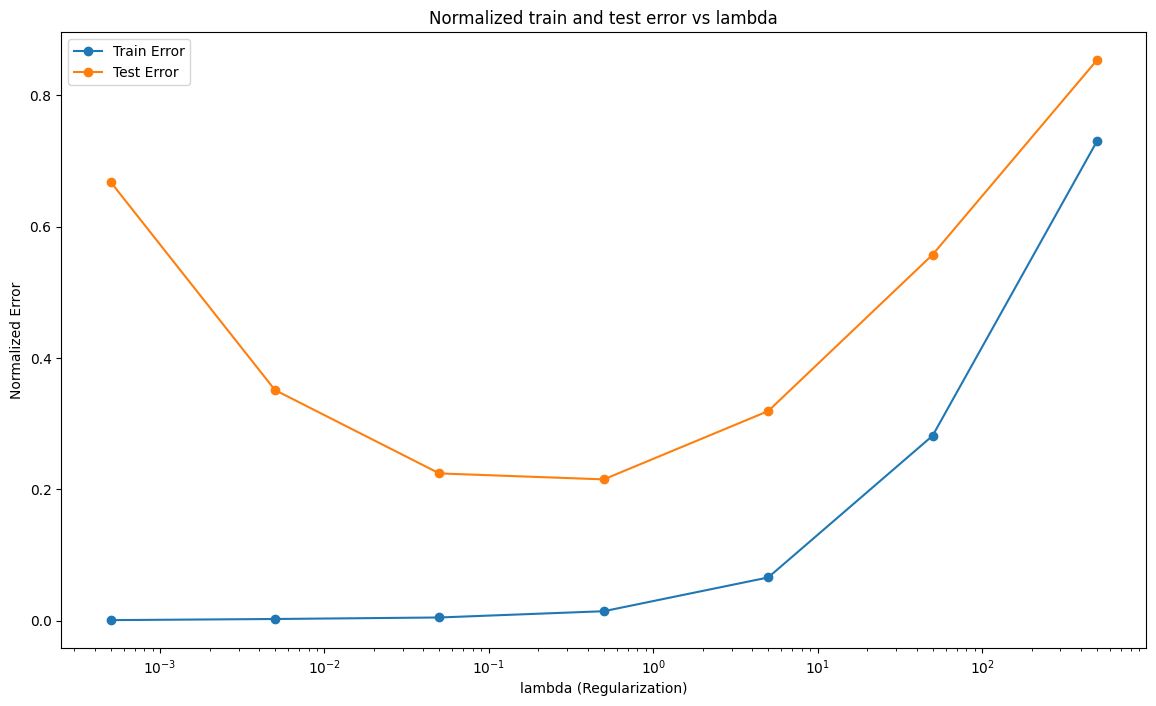

In [66]:
n_trials = 10
l_reg_list = [0.0005, 0.005, 0.05, 0.5, 5, 50, 500]
avg_f_hat_train_per_l, avg_f_hat_test_per_l = [0.0]* len(l_reg_list), [0.0]* len(l_reg_list)
    
for t in trange(n_trials):
    w_true, X_train, y_train, X_test, y_test = generate_data()
    for l_idx, l_reg in enumerate(l_reg_list):
        XTX = X_train.T@X_train
        XTy = X_train.T@y_train
        LambdaI = l_reg*np.eye(train_n,d)
        w = np.linalg.inv(XTX+LambdaI)@XTy

        avg_f_hat_train_per_l[l_idx] += normalized_error(X_train, y_train, w)
        avg_f_hat_test_per_l[l_idx] += normalized_error(X_test, y_test, w)  

avg_f_hat_train_per_l = [x/n_trials for x in avg_f_hat_train_per_l]
avg_f_hat_test_per_l = [x/n_trials for x in avg_f_hat_test_per_l]            
        # pass  # TODO: implement and update avg_f_hat_train_per_l, avg_f_hat_test_per_l

fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='o', label='Train Error')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='o', label='Test Error')
axs.set_xscale('log')
axs.set_xlabel('lambda (Regularization)')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs lambda')
axs.legend()

print(f"Normalized train error (L2 linalg soln): {avg_f_hat_train_per_l}")
print(f"Normalized test error (L2 linalg soln): {avg_f_hat_test_per_l}")


# 3.3

In [67]:
def sgd(X, y, w, step_size, n_steps):    
    w_sgd = w
    for _ in trange(n_steps): 
        i=np.random.randint(train_n)
        x_i = X[i].reshape(1,d) 
        y_i = y[i].reshape(1,1)
        sgd = 2*x_i.T@(x_i@w-y_i)
        w_sgd = w_sgd-step_size*sgd
    return w_sgd

In [68]:
n_trials = 10
step_size_list = [5e-5, 5e-4, 5e-3]
avg_f_hat_train_per_ss, avg_f_hat_test_per_ss = [0.0]* len(step_size_list), [0.0]* len(step_size_list)
    
for t in trange(n_trials, desc="Trail #"):
    w_true, X_train, y_train, X_test, y_test = generate_data()
    for ss_idx, step_size in enumerate(step_size_list):
        w = np.zeros((d,1))
        w = sgd(X_train, y_train, w, step_size, 100000)
        avg_f_hat_train_per_ss[ss_idx] += normalized_error(X_train,y_train,w)
        avg_f_hat_test_per_ss[ss_idx] += normalized_error(X_test,y_test,w)

        # pass  # TODO: implement and update avg_f_hat_train_per_ss, avg_f_hat_test_per_ss

avg_f_hat_train_per_ss = [x/n_trials for x in avg_f_hat_train_per_ss]
avg_f_hat_test_per_ss = [x/n_trials for x in avg_f_hat_test_per_ss]  

print(f"Normalized train error (SGD): {avg_f_hat_train_per_ss}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_ss}")

Trail #:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

...

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

Normalized train error (SGD): [np.float64(21.29783078268859), np.float64(220.75587125858746), np.float64(2211.996329740093)]
Normalized test error (SGD): [np.float64(12.851618283953286), np.float64(134.46983100892356), np.float64(1349.2136352579523)]


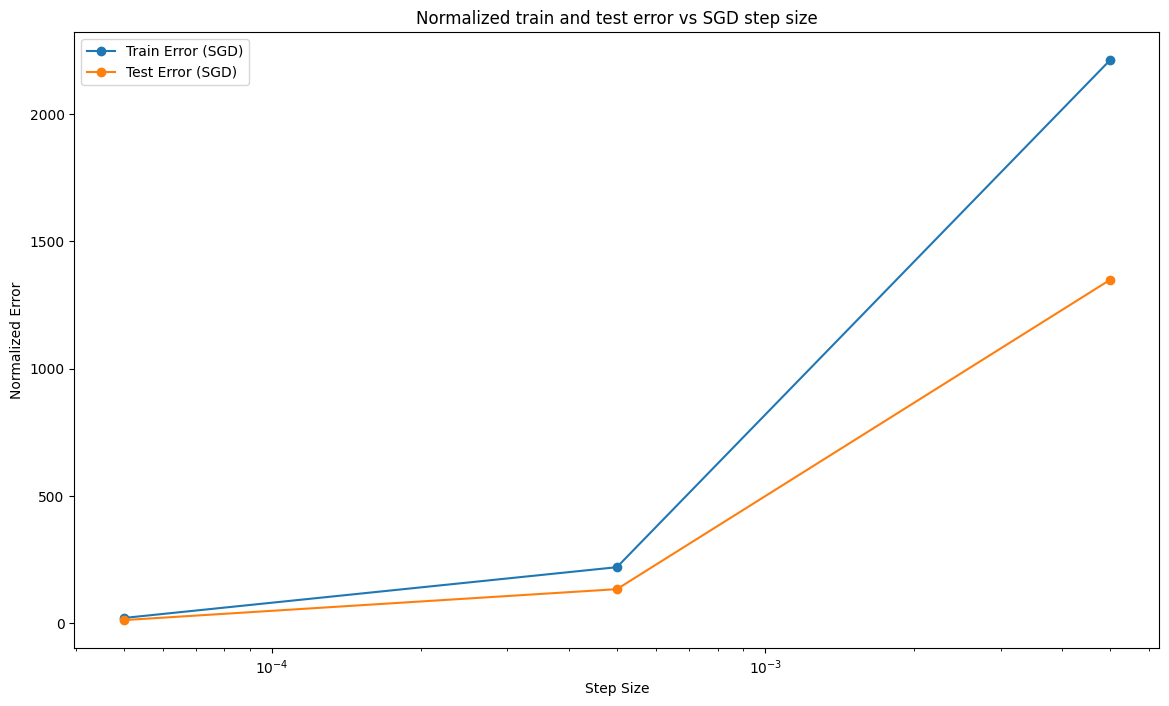

In [70]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(step_size_list, avg_f_hat_train_per_ss, marker='o', label='Train Error (SGD)')
axs.plot(step_size_list, avg_f_hat_test_per_ss, marker='o', label='Test Error (SGD)')
axs.set_xscale('log')
axs.set_xlabel('Step Size')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()

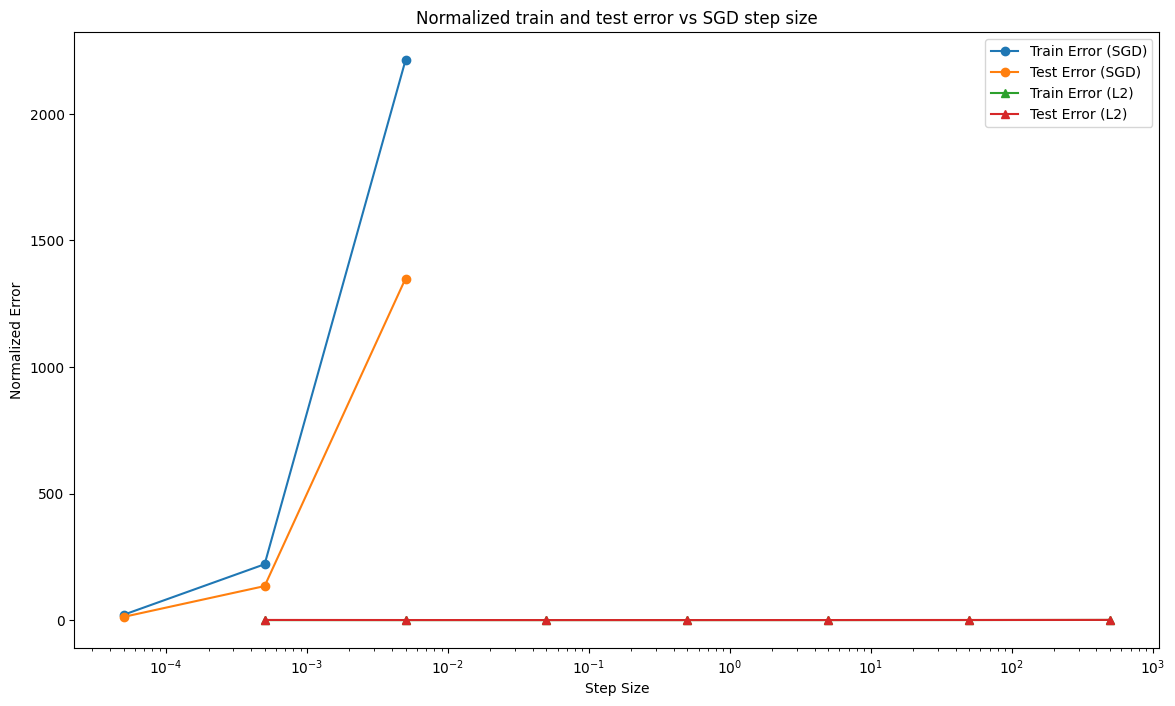

In [71]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(step_size_list, avg_f_hat_train_per_ss, marker='o', label='Train Error (SGD)')
axs.plot(step_size_list, avg_f_hat_test_per_ss, marker='o', label='Test Error (SGD)')
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='^', label='Train Error (L2)')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='^', label='Test Error (L2)')
axs.set_xscale('log')
axs.set_xlabel('Step Size')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()

# 3.4

In [97]:
def sgd_w_tracking(X, y, X_te, y_te, w, step_size, n_steps, eval_every=100):
    train_errs, test_errs, w_norms = [], [], []
    print(f"Step size: {step_size}")
    w_sgd = w
    for step_ctr in trange(n_steps, desc="SGD iteration"):
        i=np.random.randint(X.shape[0])
        x_i = X[i].reshape(1,d) 
        y_i = y[i].reshape(1,1)
        sgd = 2*x_i.T@(x_i@w_sgd-y_i)
        w_sgd = w_sgd-step_size*sgd  
        if step_ctr%eval_every == 0:      
            train_errs.append(normalized_error(X, y, w_sgd))
            test_errs.append(normalized_error(X_te, y_te, w_sgd))
            w_norms.append(np.linalg.norm(w_sgd))
        # pass  # TODO: implement and update train_errs, test_errs, w_norms
        
    return w_sgd, train_errs, test_errs, w_norms

In [98]:
step_size_list = [5e-5, 5e-3]
f_hat_train_trend_per_ss, f_hat_test_trend_per_ss, w_norm_trend = [None]* len(step_size_list), [None]* len(step_size_list), [None]* len(step_size_list)
f_hat_train_true, f_hat_test_true = [], []
    
w_true, X_train, y_train, X_test, y_test = generate_data()
f_hat_train_true = normalized_error(X_train, y_train, w_true)
f_hat_test_true = normalized_error(X_test, y_test, w_true)

for ss_idx, step_size in enumerate(step_size_list):

    w = np.zeros((d,1))
    w, train_errors, test_errors, w_est_norms = sgd_w_tracking(X_train,y_train,X_test,y_test,w,step_size,1000000)
    # pass  # TODO: compute w_est, train_errors, test_errors, w_est_norms for each step size

    f_hat_train_trend_per_ss[ss_idx] = train_errors
    f_hat_test_trend_per_ss[ss_idx] = test_errors
    w_norm_trend[ss_idx] = w_est_norms

Step size: 5e-05


SGD iteration:   0%|          | 0/1000000 [00:00<?, ?it/s]

Step size: 0.005


SGD iteration:   0%|          | 0/1000000 [00:00<?, ?it/s]

### 3.4 (i)

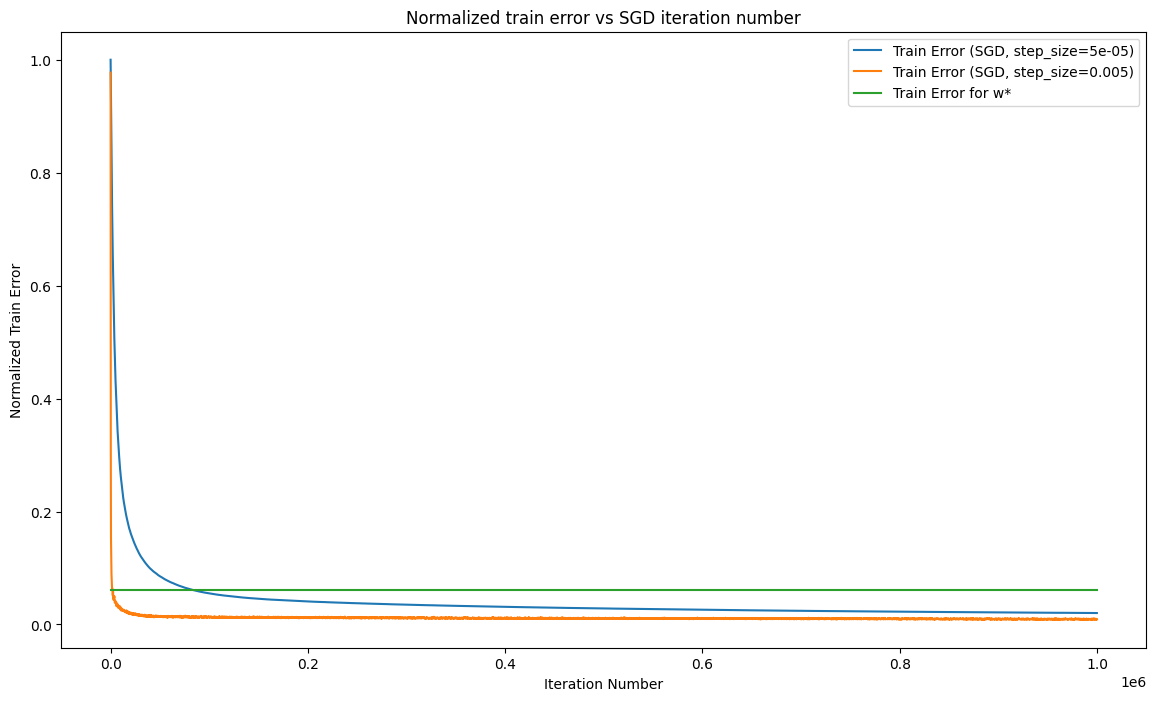

In [99]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000000, step=100), f_hat_train_trend_per_ss[ss_idx],
             label=f'Train Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_train_true, f_hat_train_true], label='Train Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Train Error')
axs.set_title('Normalized train error vs SGD iteration number')
axs.legend()

### 3.4 (ii)

10000


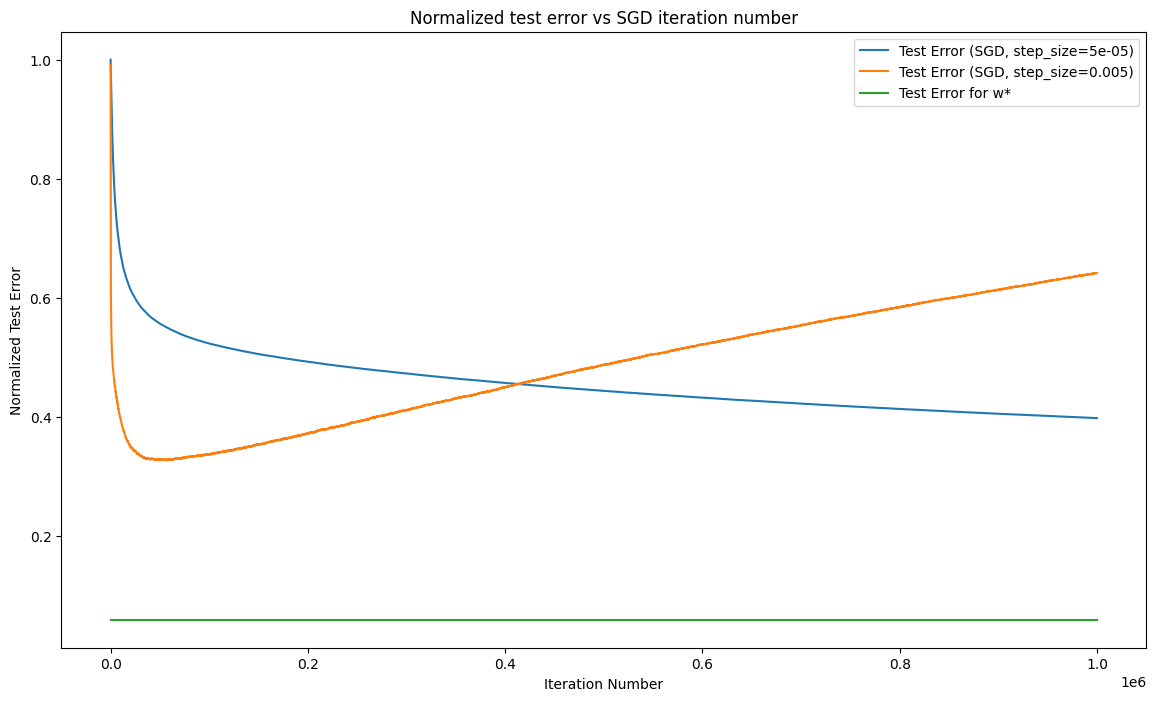

In [100]:
print(len(f_hat_test_trend_per_ss[0]))
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000000, step=100), f_hat_test_trend_per_ss[ss_idx],
             label=f'Test Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_test_true, f_hat_test_true], label='Test Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Test Error')
axs.set_title('Normalized test error vs SGD iteration number')
axs.legend()

### 3.4 (iii)

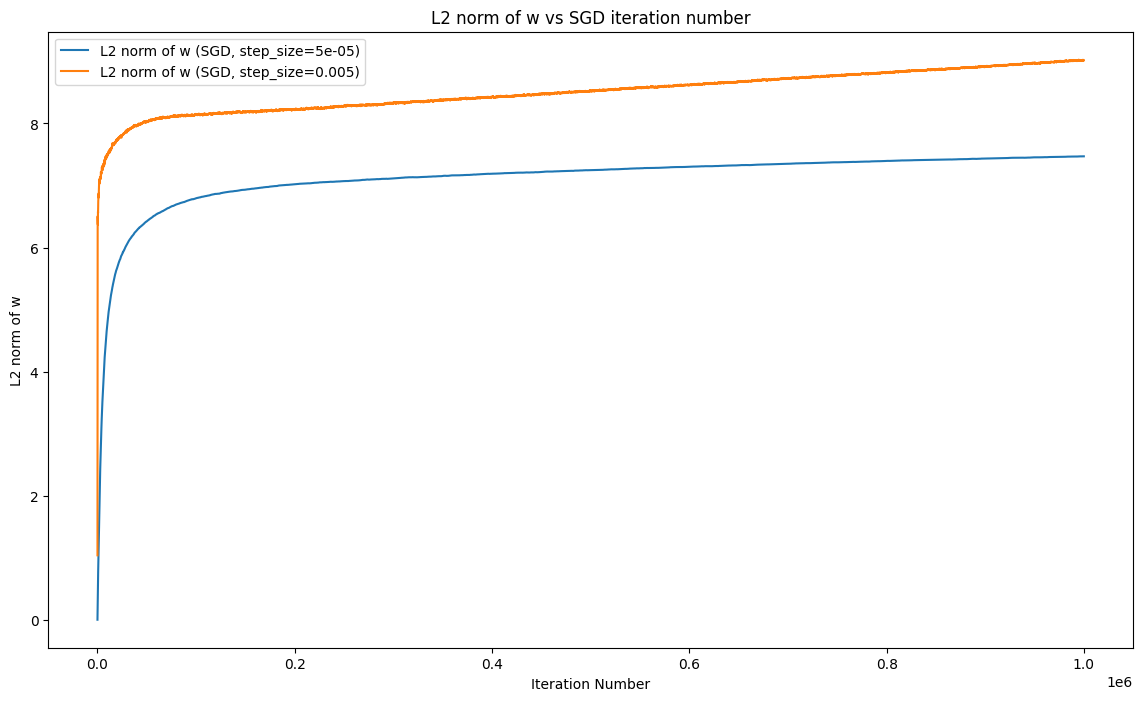

In [101]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000000, step=100), w_norm_trend[ss_idx],
             label=f'L2 norm of w (SGD, step_size={step_size})')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('L2 norm of w')
axs.set_title('L2 norm of w vs SGD iteration number')
axs.legend()

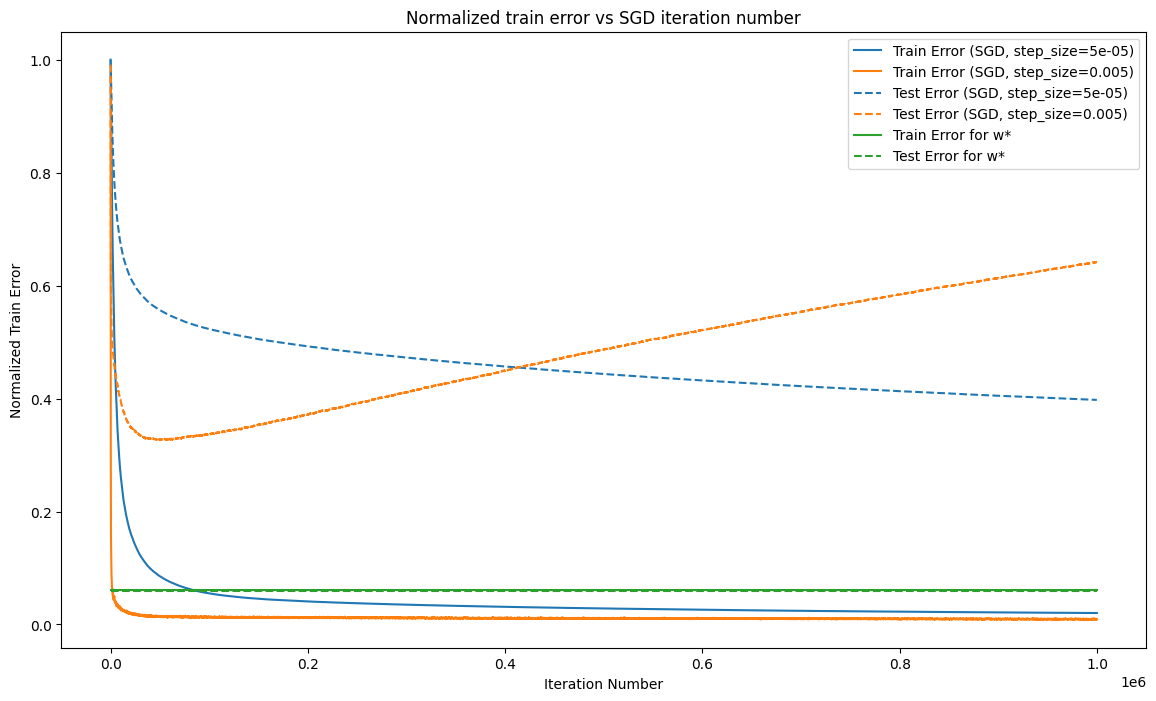

In [104]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000000, step=100), f_hat_train_trend_per_ss[ss_idx], f'C{ss_idx}',
             label=f'Train Error (SGD, step_size={step_size})')

for ss_idx, step_size in enumerate(step_size_list):
    axs.plot(np.arange(1000000, step=100), f_hat_test_trend_per_ss[ss_idx], f'C{ss_idx}--',
             label=f'Test Error (SGD, step_size={step_size})')

axs.plot([0, 1000000], [f_hat_train_true, f_hat_train_true], 'C2', label='Train Error for w*')
axs.plot([0, 1000000], [f_hat_test_true, f_hat_test_true], 'C2--', label='Test Error for w*')

axs.set_xlabel('Iteration Number')
axs.set_ylabel('Normalized Train Error')
axs.set_title('Normalized train error vs SGD iteration number')
axs.legend()

# 3.5

In [115]:
n_trials = 10
r_list = [0, 0.1, 0.5, 1, 10, 20, 30]
avg_f_hat_train_per_r, avg_f_hat_test_per_r, w_norm_per_r = [0.0]* len(r_list), [0.0]* len(r_list), [0.0]* len(r_list)

for t in trange(n_trials, desc="Trail #"):
    w_true, X_train, y_train, X_test, y_test = generate_data()  
    for r_idx, r_size in enumerate(r_list):
        w_rand = np.random.normal(0,1,size=(d,1))
        w_l2 = np.linalg.norm(w_rand)
        w = w_rand/w_l2*r_size
        w = sgd(X_train, y_train, w, 5e-5, 1000000)
        avg_f_hat_train_per_r[r_idx] += normalized_error(X_train,y_train,w)
        avg_f_hat_test_per_r[r_idx] += normalized_error(X_test,y_test,w)
avg_f_hat_train_per_r = [x/n_trials for x in avg_f_hat_train_per_r]
avg_f_hat_test_per_r = [x/n_trials for x in avg_f_hat_test_per_r]
    # pass  # TODO: implement and update avg_f_hat_train_per_r, avg_f_hat_test_per_r, w_norm_per_r

print(f"Normalized train error (SGD): {avg_f_hat_train_per_r}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_r}")

Trail #:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

Normalized train error (SGD): [np.float64(219.3091226441149), np.float64(219.42870509643777), np.float64(218.43804587084884), np.float64(219.68777420013612), np.float64(327.13500173377), np.float64(500.38118028469137), np.float64(685.9197810567886)]
Normalized test error (SGD): [np.float64(142.08060746484924), np.float64(142.16786187321546), np.float64(141.58873006666585), np.float64(142.08079693786186), np.float64(203.7740505898459), np.float64(323.6382293435787), np.float64(440.7450576937754)]


Normalized train error (SGD): [np.float64(219.3091226441149), np.float64(219.42870509643777), np.float64(218.43804587084884), np.float64(219.68777420013612), np.float64(327.13500173377), np.float64(500.38118028469137), np.float64(685.9197810567886)]
Normalized test error (SGD): [np.float64(142.08060746484924), np.float64(142.16786187321546), np.float64(141.58873006666585), np.float64(142.08079693786186), np.float64(203.7740505898459), np.float64(323.6382293435787), np.float64(440.7450576937754)]


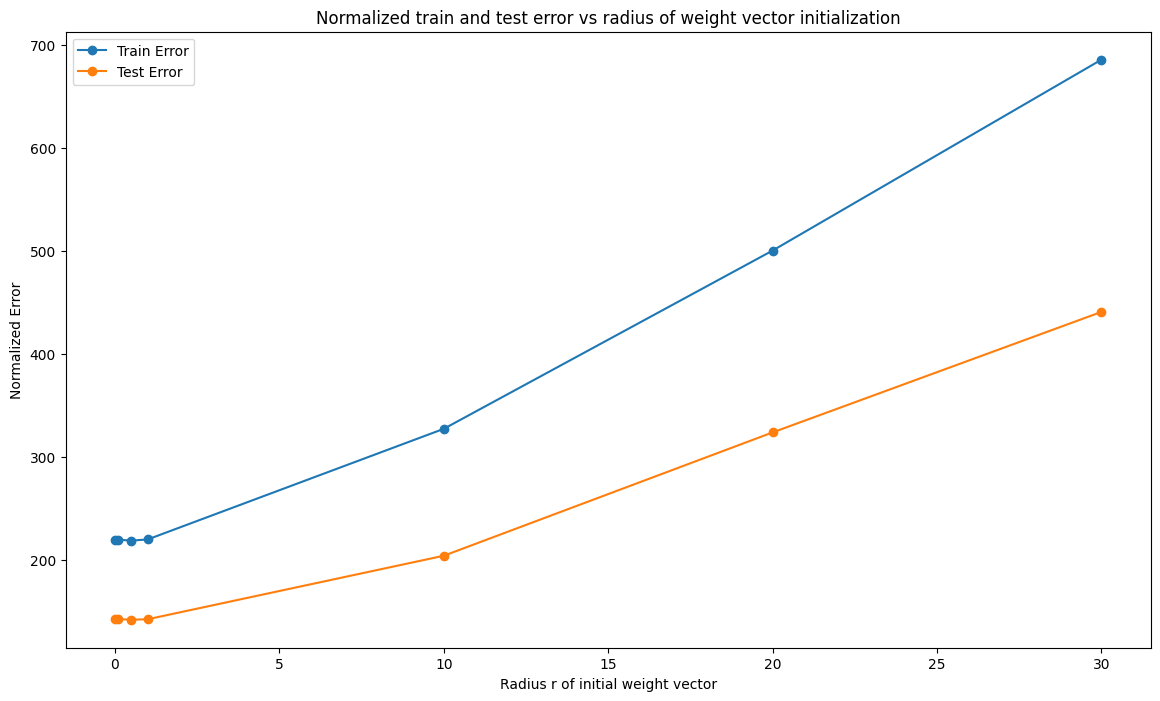

In [116]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(r_list, avg_f_hat_train_per_r, marker='o', label='Train Error')
axs.plot(r_list, avg_f_hat_test_per_r, marker='o', label='Test Error')

axs.set_xlabel('Radius r of initial weight vector')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs radius of weight vector initialization')
axs.legend()

print(f"Normalized train error (SGD): {avg_f_hat_train_per_r}")
print(f"Normalized test error (SGD): {avg_f_hat_test_per_r}")

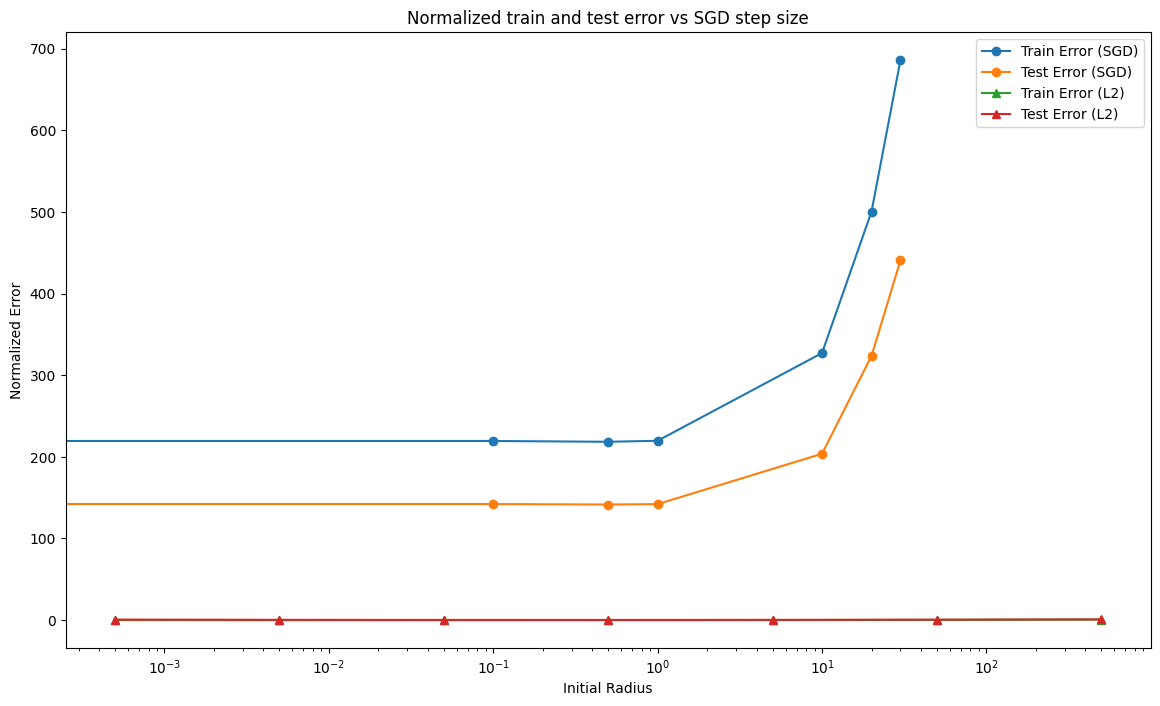

In [117]:
fig, axs = plt.subplots()
fig.set_size_inches(14, 8)
axs.plot(r_list, avg_f_hat_train_per_r, marker='o', label='Train Error (SGD)')
axs.plot(r_list, avg_f_hat_test_per_r, marker='o', label='Test Error (SGD)')
axs.plot(l_reg_list, avg_f_hat_train_per_l, marker='^', label='Train Error (L2)')
axs.plot(l_reg_list, avg_f_hat_test_per_l, marker='^', label='Test Error (L2)')
axs.set_xscale('log')
axs.set_xlabel('Initial Radius')
axs.set_ylabel('Normalized Error')
axs.set_title('Normalized train and test error vs SGD step size')
axs.legend()